# **Análisis exploratorio inicial**
Esthefania Ortega

## **0. Carga de librerías y dependencias**

In [2]:
!pip install missingno

  Using cached missingno-0.5.2-py3-none-any.whl.metadata (639 bytes)
Using cached missingno-0.5.2-py3-none-any.whl (8.7 kB)



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [296]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np

#Estilo de gráficas
plt.style.use('ggplot')

## **1. Carga de datos**

In [250]:
rick = pd.read_csv('../data/interim/rick_hist.csv')
print(f'Tamaño del dataset: {rick.shape}')
rick.head()

Tamaño del dataset: (2631, 173)


,ide_id,ide_sex,ide_eda_ano,des_cal,ide_col,des_jur_res,des_mpo_res,cve_loc_res,des_loc_res,ide_cp,...,ricket_cq,res_final_ricket_inmuno,res_final_ricket_rtpcr,fecha_resultado_rickett_rtpcr,ricket_especie_rtpcr,tratamiento_rickettsiosis,fec_ini_trat_ricket,fec_fin_trat_ricket,med_trat_ricket,des_ins_uni_trat_norm
0,928424,1,39,CALLE,PASEOS DEL PEDREGAL Fraccionamiento,HERMOSILLO,HERMOSILLO,289,HERMOSILLO,83118.0,...,0.0,0.0,1.0,2022-01-05,0.0,1,2022-01-01,2022-01-04,1,SSA
1,928745,2,8,CALLE,SAN RAFAEL Colonia,SAN LUIS RIO COLORADO,PUERTO PEÑASCO,1,PUERTO PEÑASCO,83557.0,...,0.0,0.0,2.0,2022-01-13,0.0,1,2022-01-05,NaN,1,NaN
2,928768,2,2,CALLE,EL BOSQUE (CALLE QUINCE) Ejido,CAJEME,CAJEME,365,QUETCHEHUECA,85207.0,...,NaN,NaN,NaN,NaN,NaN,1,2022-01-06,NaN,0,SSA
3,929029,1,9,PRIVADA,PUERTO PEÑASCO CENTRO Colonia,SAN LUIS RIO COLORADO,PUERTO PEÑASCO,1,PUERTO PEÑASCO,83550.0,...,0.0,0.0,2.0,2022-01-13,0.0,1,2022-01-10,NaN,1,NaN
4,929184,2,13,CALLE,PALO BLANCO Congregación,NAVOJOA,NAVOJOA,124,TESIA,85235.0,...,0.0,1.0,1.0,NaN,0.0,1,2022-01-14,NaN,1,IMSS Ordinario


## **2. Análisis general del dataset**

### 2.1 **Tamaño y variables**

In [251]:
print(rick.info())
rick.columns

<class 'pandas.DataFrame'>
RangeIndex: 2631 entries, 0 to 2630
Columns: 173 entries, ide_id to des_ins_uni_trat_norm
dtypes: float64(9), int64(126), str(38)
memory usage: 3.5 MB
None


Index(['ide_id', 'ide_sex', 'ide_eda_ano', 'des_cal', 'ide_col', 'des_jur_res',
       'des_mpo_res', 'cve_loc_res', 'des_loc_res', 'ide_cp',
       ...
       'ricket_cq', 'res_final_ricket_inmuno', 'res_final_ricket_rtpcr',
       'fecha_resultado_rickett_rtpcr', 'ricket_especie_rtpcr',
       'tratamiento_rickettsiosis', 'fec_ini_trat_ricket',
       'fec_fin_trat_ricket', 'med_trat_ricket', 'des_ins_uni_trat_norm'],
      dtype='str', length=173)

In [252]:
print('Tipos de datos:')
rick.dtypes

Tipos de datos:


ide_id                       int64
ide_sex                      int64
ide_eda_ano                  int64
des_cal                        str
ide_col                        str
                             ...  
tratamiento_rickettsiosis    int64
fec_ini_trat_ricket            str
fec_fin_trat_ricket            str
med_trat_ricket              int64
des_ins_uni_trat_norm          str
Length: 173, dtype: object

### 2.2 **Estadísticas descriptivas**

In [253]:
rick.describe().T

,count,mean,std,min,25%,50%,75%,max
ide_id,2631.0,1.238238e+06,293435.104491,928424.0,988315.0,1098727.0,1430417.0,1915009.0
ide_sex,2631.0,1.556823e+00,0.496855,1.0,1.0,2.0,2.0,2.0
ide_eda_ano,2631.0,2.432079e+01,19.557143,0.0,8.0,18.0,37.0,86.0
cve_loc_res,2631.0,1.874816e+02,248.833142,1.0,1.0,289.0,289.0,3928.0
ide_cp,2626.0,8.386622e+04,3166.888240,2240.0,83177.0,83297.0,85219.0,85994.0
...,...,...,...,...,...,...,...,...
res_final_ricket_inmuno,2440.0,4.016393e-02,0.260935,0.0,0.0,0.0,0.0,2.0
res_final_ricket_rtpcr,2440.0,1.644672e+00,0.627029,0.0,1.0,2.0,2.0,3.0
ricket_especie_rtpcr,2440.0,1.331967e-01,0.339857,0.0,0.0,0.0,0.0,1.0
tratamiento_rickettsiosis,2631.0,8.950969e-01,0.434731,0.0,1.0,1.0,1.0,2.0


In [254]:
print("Estadísticas descriptivas categóricas")
rick.describe(include=['object']).T

Estadísticas descriptivas categóricas


C:\Users\fanny\AppData\Local\Temp\ipykernel_16376\3785919981.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  rick.describe(include=['object']).T


,count,unique,top,freq
des_cal,2631,22,CALLE,2127
ide_col,2631,828,MIGUEL ALEMÁN CENTRO Colonia,40
des_jur_res,2631,15,HERMOSILLO,1515
des_mpo_res,2631,52,HERMOSILLO,1474
des_loc_res,2631,244,HERMOSILLO,1289
des_cual_lengua,34,10,Yaqui,9
des_ocupacion,2631,19,Estudiantes,977
fec_sol_aten,2631,895,2024-08-20,15
fec_ini_estudio,2631,857,2023-08-28,19
fec_fin_estudio,1361,626,2022-10-17,12


## **3. Valores faltantes**

In [255]:
# Calcular cantidad y porcentaje de nulos
null_counts = rick.isna().sum()
null_percentages = (rick.isna().sum() / len(rick)) * 100

# Crear un dataframe de resumen
faltantes_df = pd.DataFrame({
    'Faltantes': null_counts,
    'Porcentaje (%)': null_percentages.round(2)
}).sort_values(by='Porcentaje (%)', ascending=False)

print("Análisis de valores faltantes:")
print(f"Variables con al menos 1 valor faltante: {len(faltantes_df[faltantes_df['Faltantes'] > 0])} / {rick.shape[1]}")
faltantes_df[faltantes_df['Faltantes'] > 0]


Análisis de valores faltantes:
Variables con al menos 1 valor faltante: 37 / 173


,Faltantes,Porcentaje (%)
des_cual_lengua,2597,98.71
otros_especifique,2493,94.75
contacto_otr,2314,87.95
fec_defuncion,2291,87.08
fec_ini_signos_alarma,2211,84.04
otro_sintoma,2140,81.34
otr_serv_atencion,2006,76.24
fec_fin_trat_ricket,1806,68.64
compromiso_organos,1760,66.89
fecha_resultado_rickett_ser1,1640,62.33


In [256]:
# Filas que tienen más del 50% de sus datos faltantes
umbral = 0.5
filas_vacias = rick[rick.isna().mean(axis=1) > umbral]
print(f"Registros con más del {umbral*100}% de nulos: {len(filas_vacias)}")

Registros con más del 50.0% de nulos: 0


<Axes: >

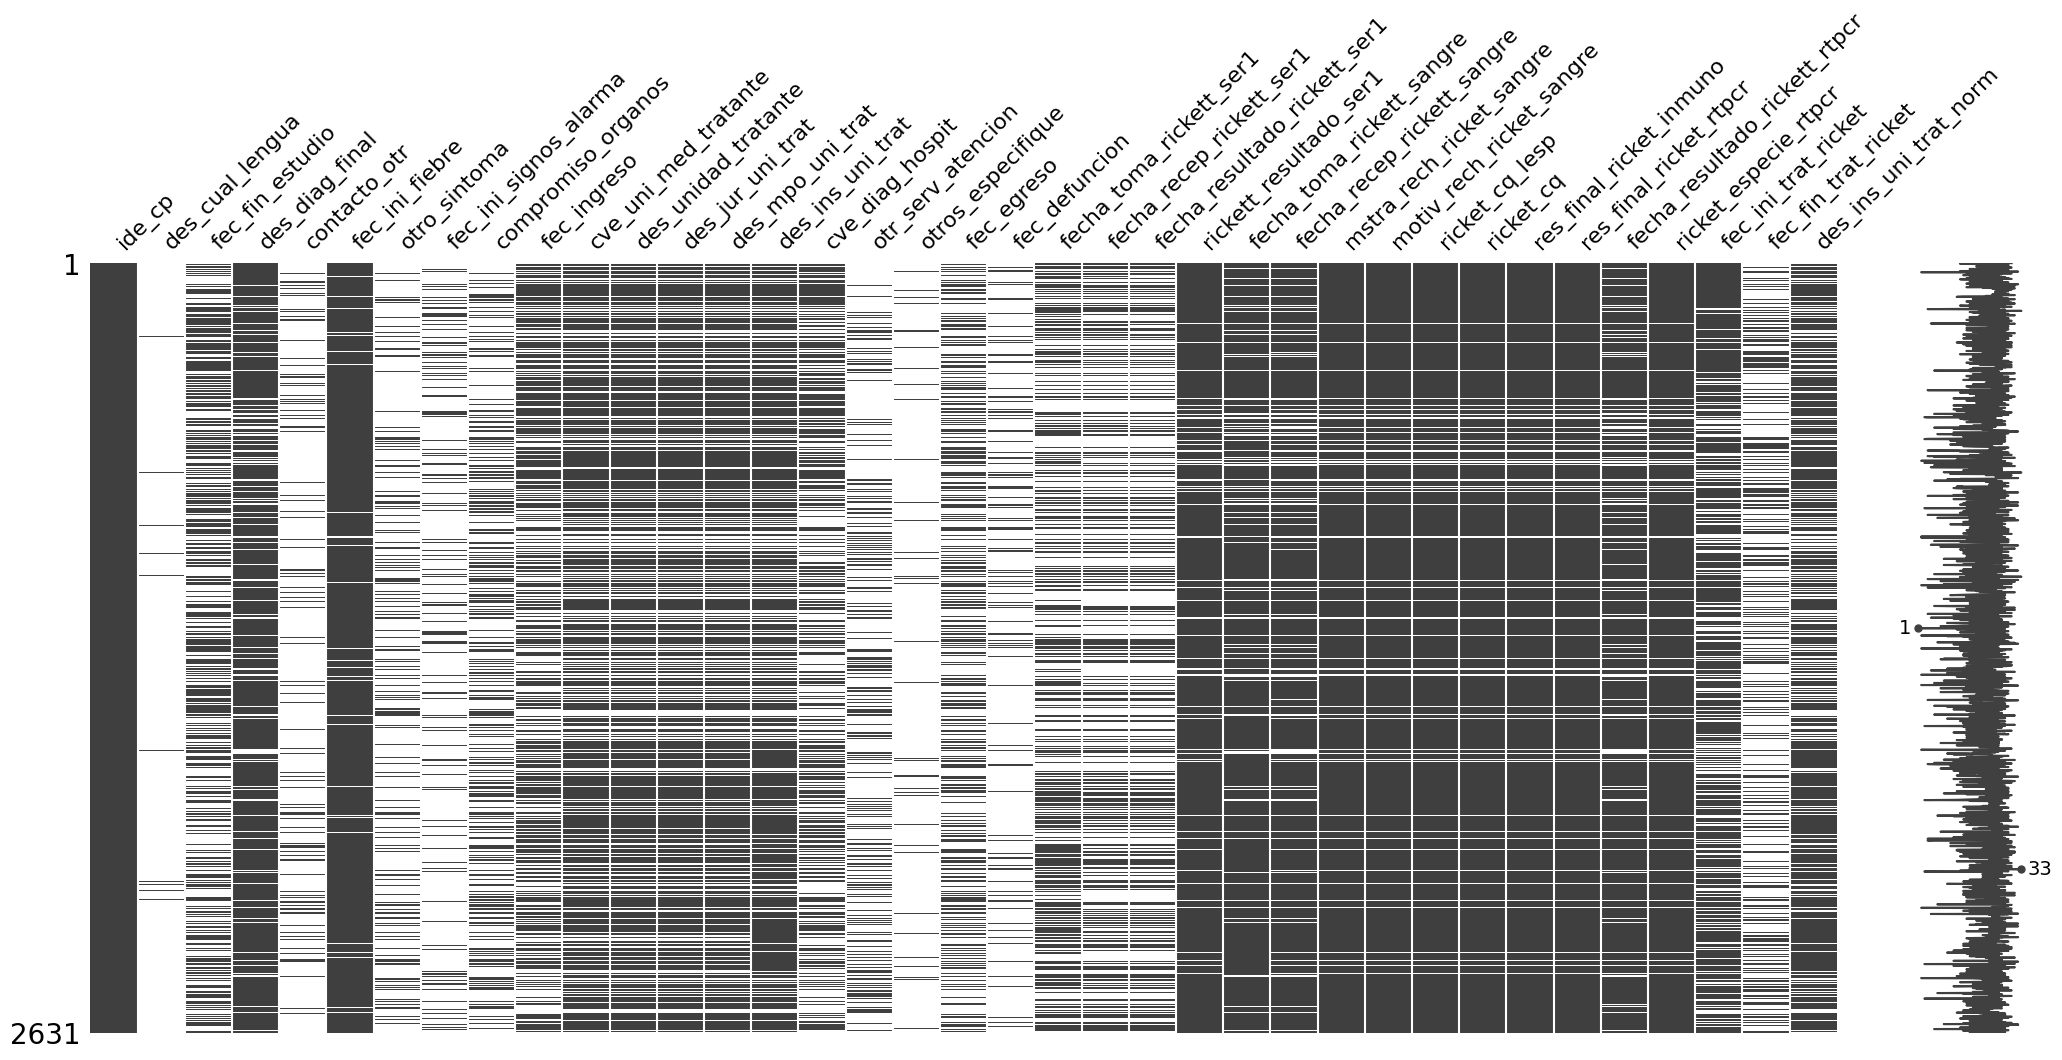

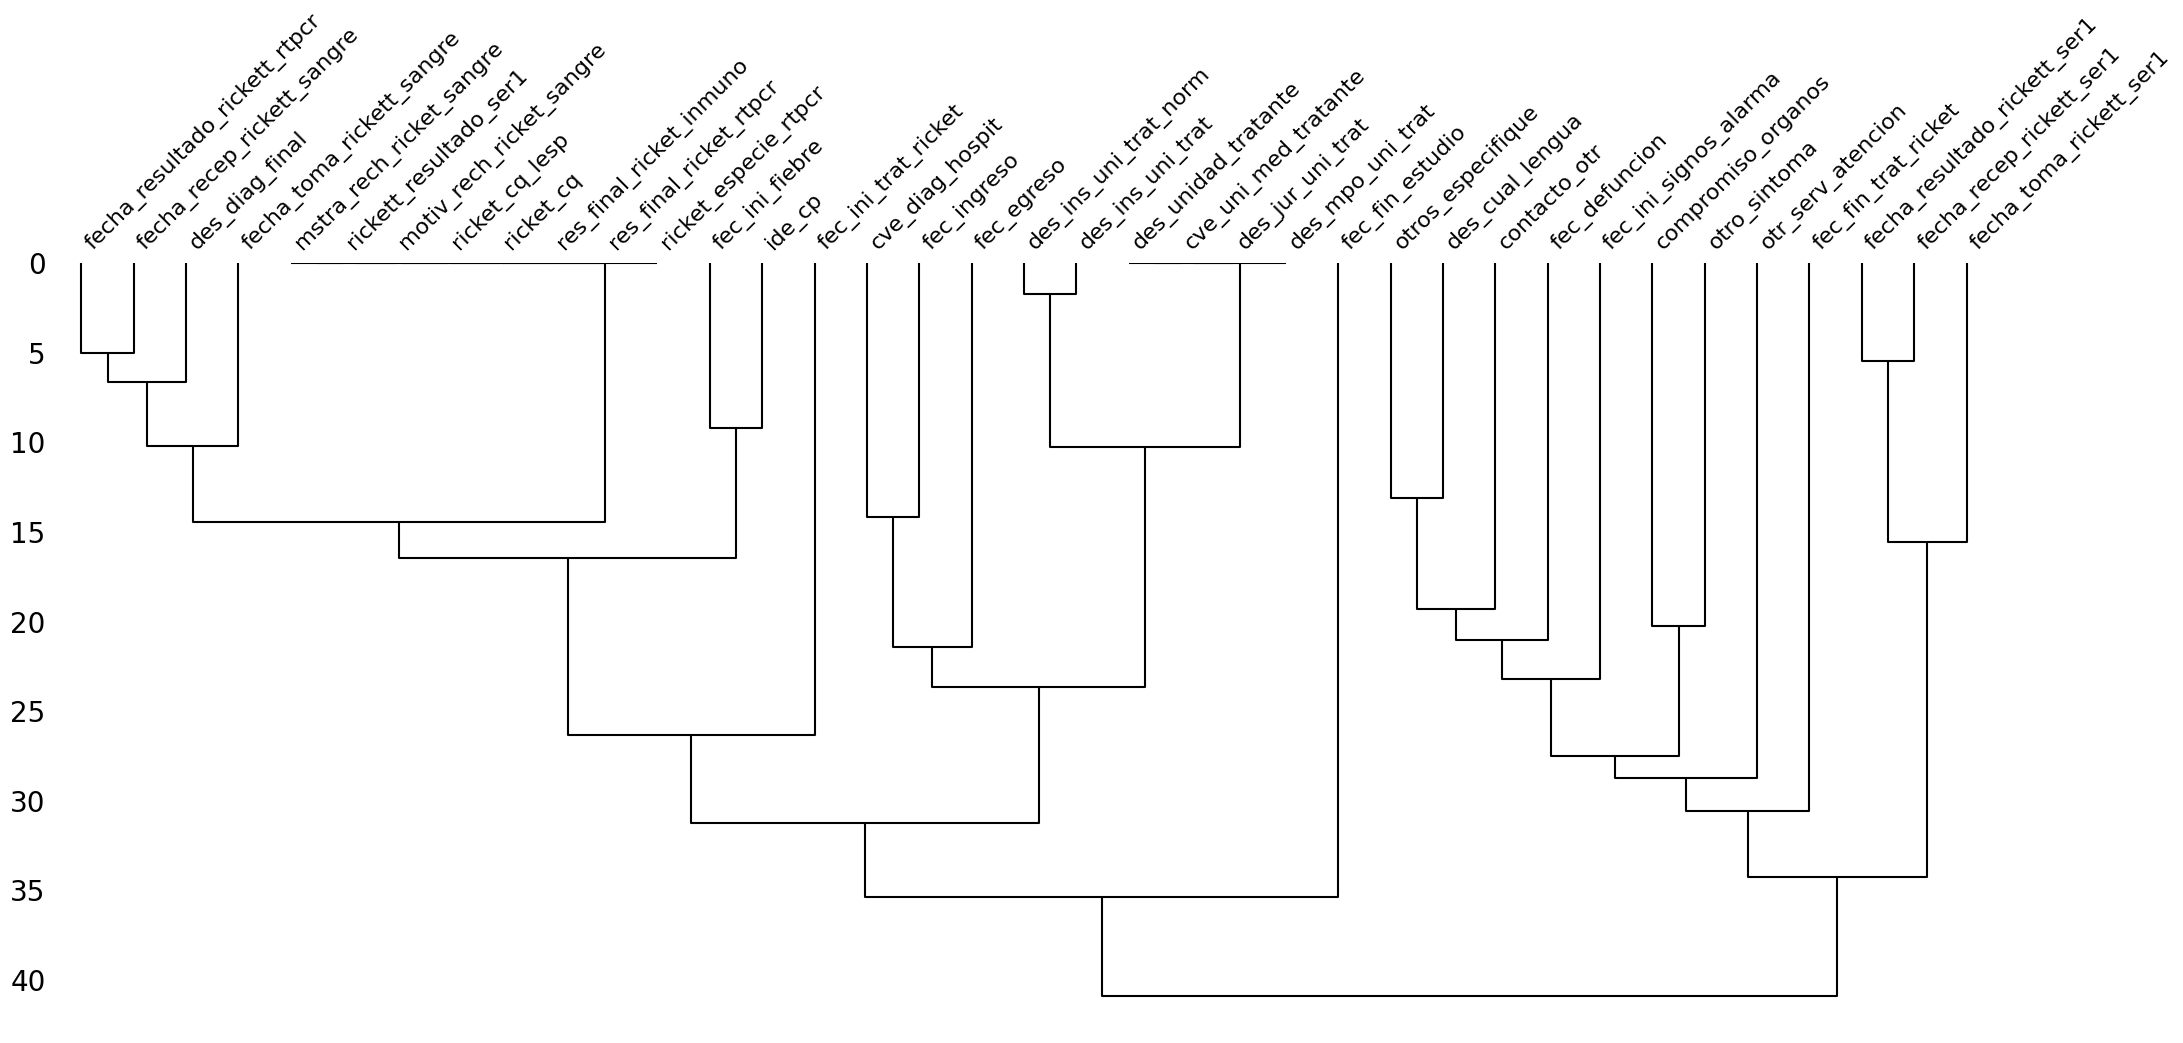

In [257]:
# Identificar columnas que tienen al menos un valor nulo
null_cols = rick.columns[rick.isna().any()].tolist()


# Matriz de completitud
msno.matrix(rick[null_cols])

# Dendrograma: muestra qué variables suelen faltar juntas
msno.dendrogram(rick[null_cols])

<Axes: >

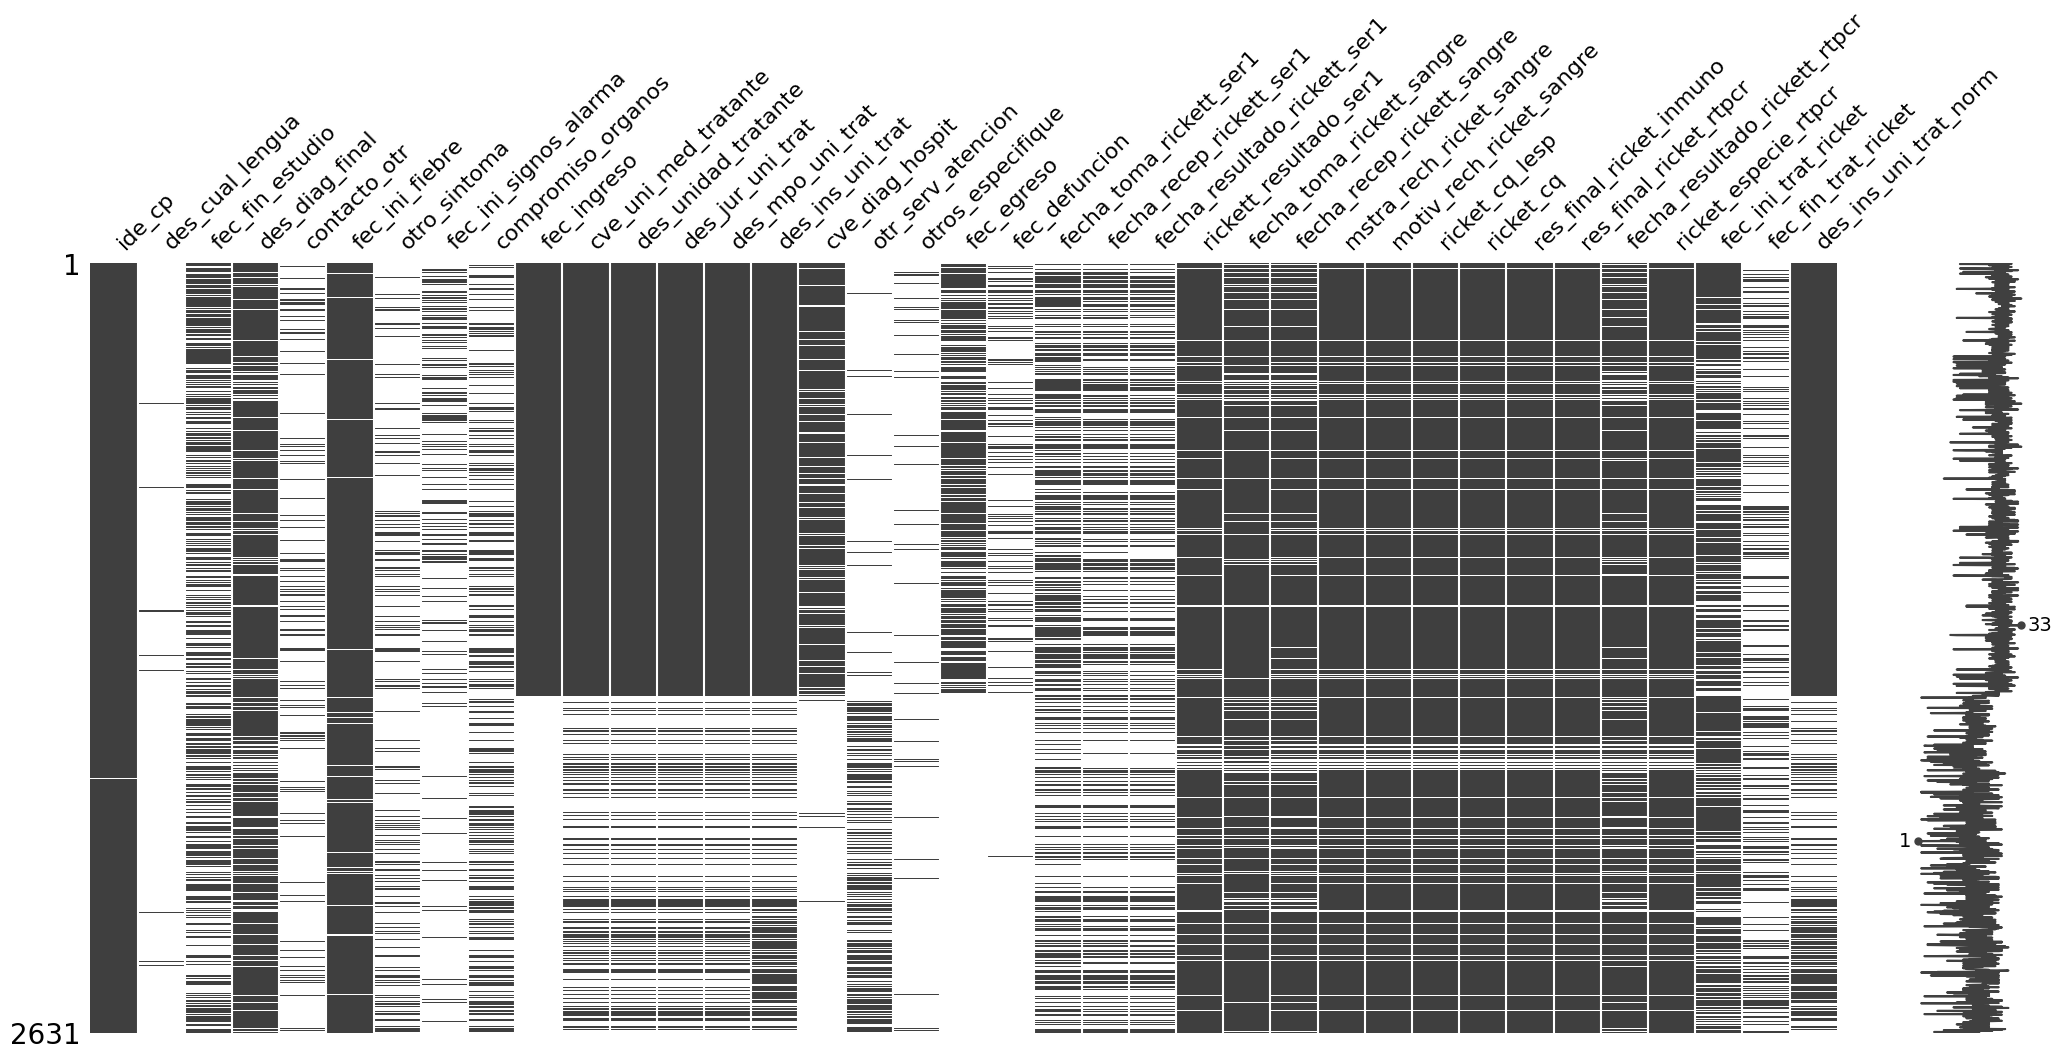

In [258]:
sorted = rick.sort_values('fec_ingreso')
msno.matrix(sorted[null_cols])

### **3.1 Imputación**

In [259]:
# Feature 'des_cual_lengua' - Lengua que habla el paciente

#Indicador de filas imputadas 
rick['des_cual_lengua_imput'] = rick['des_cual_lengua'].isnull().astype('category')

# Imputaremos lo valores nulos con 'Otro' para no perder información
rick['des_cual_lengua'] = rick['des_cual_lengua'].fillna('Otro')
rick['des_cual_lengua'].value_counts(dropna=False)

C:\Users\fanny\AppData\Local\Temp\ipykernel_16376\2166021503.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rick['des_cual_lengua_imput'] = rick['des_cual_lengua'].isnull().astype('category')


des_cual_lengua
Otro          2597
Yaqui            9
Guarijío         7
Triqui           5
Mayo             4
Seri             3
Tzeltal          2
Tarahumara       1
Mixteco          1
Náhuatl          1
Totonaca         1
Name: count, dtype: int64

In [260]:
# Feature 'otros_especifique' - El paciente presenta otra comorbilidad
#Indicador de filas imputadas 
rick['otros_especifique_imput'] = rick['otros_especifique'].isnull().astype('category')

# Imputaremos lo valores nulos con 'No' para no perder información
rick['otros_especifique'] = rick['otros_especifique'].fillna('No')
rick['otros_especifique'].value_counts(dropna=False)

C:\Users\fanny\AppData\Local\Temp\ipykernel_16376\2757969430.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rick['otros_especifique_imput'] = rick['otros_especifique'].isnull().astype('category')


otros_especifique
No                                    2493
ASMA                                    14
HIPOTIROIDISMO                          11
EPILEPSIA                                7
HIPERPLASIA PROSTATICA BENIGNA           4
                                      ... 
DERMATITIS ATOPICA                       1
DESGARRO HOMBRO / GONARTROSIS            1
LINFOMA DE HODKING                       1
ENFERMEDAD DE LYNE, HIPOTIROIDISMO       1
SINUSITIS CRONICA                        1
Name: count, Length: 99, dtype: int64

In [261]:
rick['contacto_otr'].unique()

<StringArray>
[                   nan,              'RATONES',               'PERROS',
  'CUENTA CON 2 PERROS',               'NEGADO', 'PERROS CON GARRAPATA',
             'ZOONOSIS',                  'CAN',                'PERRO',
             '2 PERROS',     'PERRO PARASITADO',    'PERROS CALLEJEROS',
            '20 PERROS', 'PERRO  ECTOPARASITOS', 'NATURALEZA E INSECTO',
                   'NO', 'PERRO CON GARRAPATAS',             '8 PERROS',
             '6 PERROS',         'PERRO Y GATO',       'PACIENTESEDADO',
  'PERRO CON RICKETSIA', 'PERRO CON ECTOPARASI',       'GATOS Y PERROS',
                'CANES', 'PERRO + ECTOPARASITO',               'PULGAS',
       'PERROS Y GATOS',              'PERRO ,',      'PERROS CABALLOS',
             'NEGATIVO',             '3 PERROS', '3 PERROS ECTOPARASIT',
 'PERROS + ECTOPARASIT', 'PERROS ECTOPARASITOS',              'CONEJOS',
                'GATOS',      'NIEGA PRESENCIA',       'TIENE MASCOTAS',
  'PLAGA DE GARRAPATAS',             

In [262]:
mapa_contacto_otr = {
    # ── SIN CONTACTO / NEGADO ────────────────────────────────────────────────
    'NEGADO':               'Sin contacto',
    'NEGATIVO':             'Sin contacto',
    'NO':                   'Sin contacto',
    'NIEGA PRESENCIA':      'Sin contacto',
    'NO HA VISTO':          'Sin contacto',

    # ── SE IGNORA ────────────────────────────────────────────────────────────
    'SE IGNORA':            'Se ignora',
    'PACIENTESEDADO':       'Se ignora',

    # ── SOLO PERROS (sin mención de ectoparásitos) ───────────────────────────
    'PERRO':                'Perros',
    'PERRO ,':              'Perros',
    'CAN':                  'Perros',
    'CANES':                'Perros',
    'PERROS':               'Perros',
    '2 PERROS':             'Perros',
    '3 PERROS':             'Perros',
    '6 PERROS':             'Perros',
    '8 PERROS':             'Perros',
    '20 PERROS':            'Perros',
    'PERROS 9':             'Perros',
    'CUENTA CON 2 PERROS':  'Perros',
    'TIENE PERROS SU CASO': 'Perros',
    'PERROS EN SU CASA':    'Perros',
    'PERROS CALLEJEROS':    'Perros',

    # ── PERRO CON ECTOPARÁSITOS ──────────────────────────────────────────────
    'PERRO PARASITADO':     'Perros con ectoparásitos',
    'PERRO  ECTOPARASITOS': 'Perros con ectoparásitos',
    'PERRO ECTOPARASITOS':  'Perros con ectoparásitos',
    'PERRO CON ECTOPARASI': 'Perros con ectoparásitos',
    'PERRO CON EXTOPARASI': 'Perros con ectoparásitos',
    'PERRO + ECTOPARASITO': 'Perros con ectoparásitos',
    'PERROS + ECTOPARASIT': 'Perros con ectoparásitos',
    'PERROS CON ECTOPARAS': 'Perros con ectoparásitos',
    'PERROS ECTOPARASITOS': 'Perros con ectoparásitos',
    '3 PERROS ECTOPARASIT': 'Perros con ectoparásitos',
    'PERRO C/ ECTOPARASIT': 'Perros con ectoparásitos',

    # ── PERRO CON GARRAPATAS ─────────────────────────────────────────────────
    'PERROS CON GARRAPATA': 'Perros con garrapatas',
    'PERRO CON GARRAPATAS': 'Perros con garrapatas',
    'PERRO CON RICKETSIA':  'Perros con garrapatas',
    'PERROCON GARRAPATAS':  'Perros con garrapatas',
    'PERROS + GARRAPATAS':  'Perros con garrapatas',
    'PERROVECINOGARRAPATA': 'Perros con garrapatas',
    'CASA/PERRO GARRAPATA': 'Perros con garrapatas',

    # ── PERRO Y GATO ─────────────────────────────────────────────────────────
    'PERRO Y GATO':         'Perros y gatos',
    'PERRO , GATO':         'Perros y gatos',
    'PERRO/GATOS':          'Perros y gatos',
    'PERRO Y GATOS':        'Perros y gatos',
    'GATOS Y PERROS':       'Perros y gatos',
    'PERROS Y GATOS':       'Perros y gatos',
    '5 PERROS Y 13 GATOS':  'Perros y gatos',
    'COCHIS,PERROS Y GATO': 'Perros y gatos',

    # ── SOLO GATOS ───────────────────────────────────────────────────────────
    'GATO':                 'Gatos',
    'GATOS':                'Gatos',

    # ── ROEDORES ─────────────────────────────────────────────────────────────
    'RATONES':              'Roedores',
    'RATAS':                'Roedores',
    'ROEDORES':             'Roedores',

    # ── OTROS ANIMALES ───────────────────────────────────────────────────────
    'CONEJOS':              'Conejos',
    'PERROS CABALLOS':      'Perros y caballos',
    'TIENE MASCOTAS':       'Otros animales',

    # ── GARRAPATAS / INSECTOS (sin animal específico) ────────────────────────
    'PLAGA DE GARRAPATAS':  'Garrapatas',
    'GARRAPATA EN CASA':    'Garrapatas',
    'SE RETIRO GARRAPATA':  'Garrapatas',
    'PULGAS':               'Pulgas',
    'ARAÑAS':               'Arañas',
    'PICADURA DE INSECTO':  'Insectos no especificados',
    'NATURALEZA E INSECTO': 'Insectos no especificados',
    
    # ZOONOSIS (sin animal específico) ─────────────────────────────────────────
    'ZOONOSIS':             'Zoonosis',
    'ZOONOSIS POSITIVA':    'Zoonosis',

    # ── EXPOSICIÓN AMBIENTAL ─────────────────────────────────────────────────
    'INTRADOMICILIARIO':    'Exposición ambiental',
    'DUERME EN EL PISO':    'Exposición ambiental',
}

rick['contacto_otr'] = rick['contacto_otr'].map(mapa_contacto_otr)

# Verificar resultado
print(rick['contacto_otr'].value_counts(dropna=False))

contacto_otr
NaN                          2315
Perros                        229
Perros con ectoparásitos       20
Perros y gatos                 19
Sin contacto                   14
Perros con garrapatas           9
Roedores                        4
Pulgas                          3
Gatos                           3
Garrapatas                      3
Zoonosis                        2
Insectos no especificados       2
Se ignora                       2
Exposición ambiental            2
Perros y caballos               1
Conejos                         1
Otros animales                  1
Arañas                          1
Name: count, dtype: int64


In [263]:
# Feature 'contacto_otr' - El paciente tuvo contacto con otro animal

#Indicador de filas imputadas 
rick['contacto_otr_imput'] = rick['contacto_otr'].isnull().astype('category')

# Imputaremos lo valores nulos con 'Se ignora' para no perder información
rick['contacto_otr'] = rick['contacto_otr'].fillna('Se ignora')
rick['contacto_otr'].value_counts(dropna=False)

C:\Users\fanny\AppData\Local\Temp\ipykernel_16376\1755125451.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rick['contacto_otr_imput'] = rick['contacto_otr'].isnull().astype('category')


contacto_otr
Se ignora                    2317
Perros                        229
Perros con ectoparásitos       20
Perros y gatos                 19
Sin contacto                   14
Perros con garrapatas           9
Roedores                        4
Pulgas                          3
Gatos                           3
Garrapatas                      3
Zoonosis                        2
Insectos no especificados       2
Exposición ambiental            2
Perros y caballos               1
Conejos                         1
Otros animales                  1
Arañas                          1
Name: count, dtype: int64

In [264]:
# Feature 'otro_sintoma' - El paciente presenta otro síntoma

#Indicador de filas imputadas 
rick['otro_sintoma_imput'] = rick['otro_sintoma'].isnull().astype('category')

# Imputaremos lo valores nulos con 'No' para no perder información
rick['otro_sintoma'] = rick['otro_sintoma'].fillna('NO')
rick['otro_sintoma'] = rick['otro_sintoma'].str.replace('NINGUNO', 'NO', regex=False)
rick['otro_sintoma'].value_counts(dropna=False)

C:\Users\fanny\AppData\Local\Temp\ipykernel_16376\2651080628.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rick['otro_sintoma_imput'] = rick['otro_sintoma'].isnull().astype('category')


otro_sintoma
NO                                                                                      2220
2                                                                                        381
IRRITABILIDAD                                                                              1
LESION TIPO PAPULA DE 0.5 CM DIAM                                                          1
TAQUIPNEA                                                                                  1
EVACUACIONES DIARREICAS                                                                    1
TROMBOCITOPENIA                                                                            1
HIPEREMIA CONJUNTIVAL                                                                      1
HIGADO                                                                                     1
HIPOTIROIDISMO                                                                             1
LESION RENAL AGUDA                                       

In [265]:
# Feature 'otr_serv_atencion' - El paciente recibió otro tipo de servicio
rick['otr_serv_atencion'].value_counts(dropna=False)

otr_serv_atencion
NaN                                      2006
EPIDEMIOLOGIA                             251
CONSULTA EXTERNA                          162
MEDICINA FAMILIAR                          66
URGENCIAS PEDIATRICAS                      44
                                         ... 
CONSULTA EXTERNA DE MEDICINA FAMILIAR       1
EPIDEMIOLOGICO                              1
CONUSLTA EPIDEMIOLOGIA                      1
MEDCINA PREVENTIVA                          1
SIN ATENCION MEDICA                         1
Name: count, Length: 74, dtype: int64

In [266]:
mapa_otr_serv_atencion = {
    # ── EPIDEMIOLOGÍA ────────────────────────────────────────────────────────
    'EPIDEMIOLOGIA':                          'Epidemiologia',
    'EPIDEMIOLOGÍA':                          'Epidemiologia',
    'EPIDEMILOGIA':                           'Epidemiologia',
    'EPIDEMIOLGIA':                           'Epidemiologia',
    'EPIEDEMIOLOGIA':                         'Epidemiologia',
    'EPIDEMIPOLOGIA':                         'Epidemiologia',
    'PIDEMIOLOGIA':                           'Epidemiologia',
    'EPIDEMILOGIA':                           'Epidemiologia',
    'EPIDEMIOLOGICA':                         'Epidemiologia',
    'EPIDEMIOLOGICO':                         'Epidemiologia',
    'EPIDEMIOLOGO':                           'Epidemiologia',
    'DEPTO. EPIDEMIOLOGIA':                   'Epidemiologia',
    'SERVICIO EPIDEMIOLOGIA':                 'Epidemiologia',
    'CONSULTA EPIDEMIOLOGIA':                 'Epidemiologia',
    'CONSULTA EPIDEMIOLOGÍA':                 'Epidemiologia',
    'CONUSLTA EPIDEMIOLOGIA':                 'Epidemiologia',
    'EPIDEMIOLOGIA CLINICA':                  'Epidemiologia',
    'EPIDEMIOLOGIA UMF NO.1':                 'Epidemiologia',
    'EPIDEMIOLOGIA COORDINACION HUATABAMPO':  'Epidemiologia',
    'EPI':                                    'Epidemiologia',

    # ── EPIDEMIOLOGÍA + CONSULTA EXTERNA ─────────────────────────────────────
    'EPIDEMIOLOGIA/MEDICINA FAMILIAR':        'Epidemiologia y consulta externa',
    'EPIDEMIOLOGIA CONSULTA EXTERNA':         'Epidemiologia y consulta externa',
    'CONSULTA EXTERNA EPIDEMIOLOGIA':         'Epidemiologia y consulta externa',
    'CONSULTA EXTERNA EPIDEMIOLOGÍA':         'Epidemiologia y consulta externa',

    # ── CONSULTA EXTERNA ─────────────────────────────────────────────────────
    'CONSULTA EXTERNA':                       'Consulta externa',
    'CONSULTA  EXTERNA':                      'Consulta externa',
    'CONSULTA EXTERA':                        'Consulta externa',
    'CONSULTA EXTERNA GENERAL':               'Consulta externa',
    'CONSULTA EXTERNA MG':                    'Consulta externa',
    'CONSULTA':                               'Consulta externa',

    # ── MEDICINA FAMILIAR ────────────────────────────────────────────────────
    'MEDICINA FAMILIAR':                      'Medicina familiar',
    'MEDICINA FAMILAIR':                      'Medicina familiar',
    'MEDICO FAMILIAR':                        'Medicina familiar',
    'MEDIFICNA FAMILIAR':                     'Medicina familiar',
    'MF':                                     'Medicina familiar',
    'UMF 68':                                 'Medicina familiar',
    'CONSULTA EXTERNA FAMILIAR':              'Medicina familiar',
    'CONSULTA EXTERNA MEDICO FAMILIAR':       'Medicina familiar',
    'CONSULTA EXTERNA DE MEDICINA FAMILIAR':  'Medicina familiar',
    'CONSULTA MEDICINA FAMILIAR':             'Medicina familiar',

    # ── MEDICINA GENERAL ─────────────────────────────────────────────────────
    'MEDICINA GENERAL':                       'Medicina general',
    'MEDICO GENERAL':                         'Medicina general',
    'MEH':                                    'Medicina general',

    # ── MEDICINA PREVENTIVA ──────────────────────────────────────────────────
    'MEDICINA PREVENTIVA':                    'Medicina preventiva',
    'MEDCINA PREVENTIVA':                     'Medicina preventiva',

    # ── INFECTOLOGÍA ─────────────────────────────────────────────────────────
    'INFECTOLOGIA':                           'Infectologia',
    'INFECTOLOGIA CAMA 209':                  'Infectologia',

    # ── URGENCIAS PEDIÁTRICAS ────────────────────────────────────────────────
    'URGENCIAS PEDIATRICAS':                  'Urgencias pediatricas',
    'URGENCIAS PEDIÁTRICAS':                  'Urgencias pediatricas',
    'URG PEDIATRICAS':                        'Urgencias pediatricas',

    # ── CUIDADOS INTENSIVOS ──────────────────────────────────────────────────
    'UNIDAD DE CUIDADOS INTENSIVOS PEDIATRICOS': 'UCI pediatrica',

    # ── BRIGADA EPIDEMIOLÓGICA ───────────────────────────────────────────────
    'BRIGADA EPIDEMIOLOGICA':                 'Brigada epidemiologica',
    'BRIGADA EPIDEMIOLÓGICA DS5':             'Brigada epidemiologica',
    'BRIGADIA EPIDEMIOLOGIA':                 'Brigada epidemiologica',
    'BRIGADA DE SALUD EPIDEMIOLOGIA':         'Brigada epidemiologica',
    'BRIGADA DE SALUD EPIDEMIOLOGICA':        'Brigada epidemiologica',
    'BRIGADA DE SALUD':                       'Brigada epidemiologica',
    'BRIGADISTA DE SALUD':                    'Brigada epidemiologica',
    'BRIGADA':                                'Brigada epidemiologica',

    # ── CONSULTA PRIVADA / FARMACIA ──────────────────────────────────────────
    'MEDICO PARTICULAR':                      'Consulta privada',
    'CONSULTORIO PRIVADO':                    'Consulta privada',
    'FARMACIA':                               'Consulta en farmacia',
    'CONSULTORIO FARMACIA DEL AHORRO':        'Consulta en farmacia',
    'CONSULTA EN FARMACIA PARTICULAR':        'Consulta en farmacia',
    'ATENCION MEDICA EN FARMACIA BENAVIDES':  'Consulta en farmacia',
    'CONSULTORIO DE FARMACIA SIMILAR SANTA CLARA 1 COL VILLAS DEL SUR': 'Consulta en farmacia',

    # ── HOSPITAL PRIVADO ─────────────────────────────────────────────────────
    'HOSPITAL SAN JOSÉ GUAYMAS':              'Hospital privado',
    'HOSPITAL SAN JOSE GUAYMAS':              'Hospital privado',

    # ── ATENCIÓN CONTINUA ────────────────────────────────────────────────────
    'ATENCION MEDICA CONTINUA':               'Atencion continua',
    'ATENCION CONTINUA':                      'Atencion continua',

    # ── SEMEFO ───────────────────────────────────────────────────────────────
    'SEMEFO':                                 'SEMEFO',

    # ── SIN ATENCIÓN MÉDICA ──────────────────────────────────────────────────
    'SIN ATENCION MEDICA':                    'Sin atencion medica',
}

rick['otr_serv_atencion'] = rick['otr_serv_atencion'].map(mapa_otr_serv_atencion)

In [267]:
# Feature 'otr_serv_atencion' - El paciente recibió otro tipo de servicio
rick['otr_serv_atencion'].value_counts(dropna=False)

otr_serv_atencion
NaN                                 2010
Epidemiologia                        273
Consulta externa                     169
Medicina familiar                     79
Urgencias pediatricas                 49
Epidemiologia y consulta externa      17
Brigada epidemiologica                 9
Consulta en farmacia                   5
Medicina preventiva                    4
Infectologia                           3
Medicina general                       3
Atencion continua                      3
Hospital privado                       2
Consulta privada                       2
SEMEFO                                 1
UCI pediatrica                         1
Sin atencion medica                    1
Name: count, dtype: int64

In [268]:
#Indicador de filas imputadas 
rick['otr_serv_atencion_imput'] = rick['otr_serv_atencion'].isna().astype('category')

# Imputaremos lo valores nulos con 'Se ignora' para no perder información
rick['otr_serv_atencion'] = rick['otr_serv_atencion'].fillna('Se ignora')
rick['otr_serv_atencion'].value_counts(dropna=False)

C:\Users\fanny\AppData\Local\Temp\ipykernel_16376\763547958.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rick['otr_serv_atencion_imput'] = rick['otr_serv_atencion'].isna().astype('category')


otr_serv_atencion
Se ignora                           2010
Epidemiologia                        273
Consulta externa                     169
Medicina familiar                     79
Urgencias pediatricas                 49
Epidemiologia y consulta externa      17
Brigada epidemiologica                 9
Consulta en farmacia                   5
Medicina preventiva                    4
Infectologia                           3
Medicina general                       3
Atencion continua                      3
Hospital privado                       2
Consulta privada                       2
SEMEFO                                 1
UCI pediatrica                         1
Sin atencion medica                    1
Name: count, dtype: int64

In [269]:
# Feature 'compromiso_organos' - El paciente presenta compromiso de órganos
rick['compromiso_organos'].unique()

<StringArray>
[                                   nan,
                                   'NO',
                                    '2',
                             'PULMONAR',
                    'NO POR EL MOMENTO',
                  'FALLA MULTIORGANICA',
                     'NINGUNO APARENTE',
                              'NINGUNO',
                                'RIÑON',
                                    '1',
            'INSUFICIENCIA RENAL AGUDA',
                             'NEGATIVO',
                          'FALLA RENAL',
                    'HEMATOMA EPIDURAL',
                       'PACIENTE GRAVE',
                     'HEPATICA Y RENAL',
                                'RENAL',
              'FALLA ORGANICA MULTIPLE',
                     'ESTADO DE CHOQUE',
                                   'SI',
         'ESTETATOSIS HEPATICA GRADO 1',
                              'NEGADOS',
                  'INSUFICIENCIA RENAL',
                           'EL CEREBRO',
  

### 3.2 **Outliers**

count    2631.00
mean       37.64
std         6.07
min         0.00
25%        38.00
50%        39.00
75%        39.00
max        43.00
Name: temperatura, dtype: float64

Nulos: 0


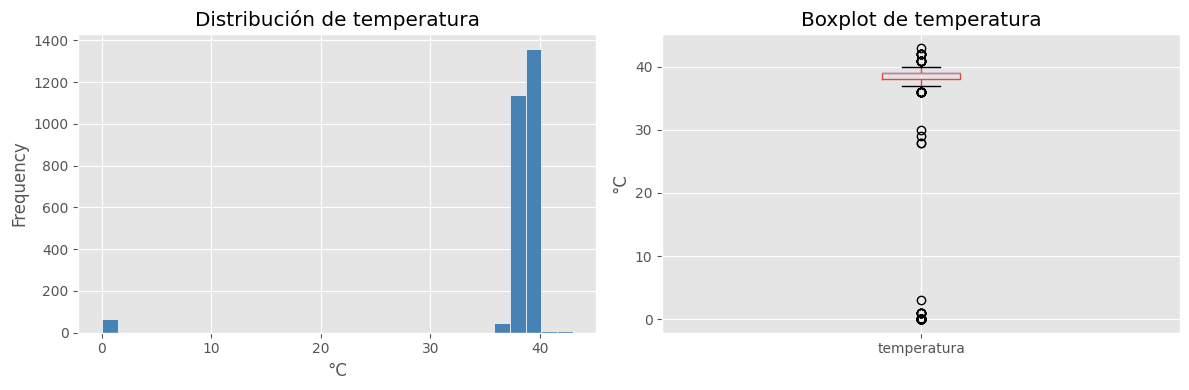

In [337]:
print(rick['temperatura'].describe().round(2))
print(f"\nNulos: {rick['temperatura'].isna().sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rick['temperatura'].plot(kind='hist', bins=30, ax=axes[0],
                         color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de temperatura')
axes[0].set_xlabel('°C')

rick.boxplot(column='temperatura', ax=axes[1])
axes[1].set_title('Boxplot de temperatura')
axes[1].set_ylabel('°C')

plt.tight_layout()
plt.show()

In [340]:
# IQR
Q1 = rick['temperatura'].quantile(0.25)
Q3 = rick['temperatura'].quantile(0.75)
IQR = Q3 - Q1
limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

outliers_iqr = rick[(rick['temperatura'] < limite_inf) |
                    (rick['temperatura'] > limite_sup)]
print(f"\nOutliers por IQR: {len(outliers_iqr)} casos")
print(f"Límites IQR: [{limite_inf:.1f}, {limite_sup:.1f}] °C")
print(outliers_iqr['temperatura'].value_counts().sort_index())


Outliers por IQR: 102 casos
Límites IQR: [36.5, 40.5] °C
temperatura
0     59
1      6
3      1
28     2
29     1
30     1
36    17
41     8
42     6
43     1
Name: count, dtype: int64


In [344]:
outliers_iqr['temperatura'].value_counts().head(25)

temperatura
0     59
36    17
41     8
1      6
42     6
28     2
29     1
3      1
43     1
30     1
Name: count, dtype: int64

## 4. Feature Engineering

### 4.1 Definir tipo de features

4.1.1 **Features de tipo datetime**

In [270]:
# Columnas datetime

#Extracción de fecha unicamente (sin hora)

# Identificar las columnas que empiezan con 'fec_'
cols_fecha = [col for col in rick.columns if col.startswith(('fec_', 'fecha'))]


for col in cols_fecha:    
    rick[col] = pd.to_datetime(rick[col], errors='coerce')

print(f"Se convirtieron {len(cols_fecha)} columnas.")
print(rick[cols_fecha].dtypes.head(20))

print("Ejemplo de conversión de fecha:")
rick[cols_fecha].head()

Se convirtieron 17 columnas.
fec_sol_aten                     datetime64[us]
fec_ini_estudio                  datetime64[us]
fec_fin_estudio                  datetime64[us]
fec_ini_signos_sint              datetime64[us]
fec_ini_fiebre                   datetime64[us]
fec_ini_signos_alarma            datetime64[us]
fec_ingreso                      datetime64[us]
fec_egreso                       datetime64[us]
fec_defuncion                    datetime64[us]
fecha_toma_rickett_ser1          datetime64[us]
fecha_recep_rickett_ser1         datetime64[us]
fecha_resultado_rickett_ser1     datetime64[us]
fecha_toma_rickett_sangre        datetime64[us]
fecha_recep_rickett_sangre       datetime64[us]
fecha_resultado_rickett_rtpcr    datetime64[us]
fec_ini_trat_ricket              datetime64[us]
fec_fin_trat_ricket              datetime64[us]
dtype: object
Ejemplo de conversión de fecha:


,fec_sol_aten,fec_ini_estudio,fec_fin_estudio,fec_ini_signos_sint,fec_ini_fiebre,fec_ini_signos_alarma,fec_ingreso,fec_egreso,fec_defuncion,fecha_toma_rickett_ser1,fecha_recep_rickett_ser1,fecha_resultado_rickett_ser1,fecha_toma_rickett_sangre,fecha_recep_rickett_sangre,fecha_resultado_rickett_rtpcr,fec_ini_trat_ricket,fec_fin_trat_ricket
0,2022-01-02,2022-01-02,2022-01-09,2021-12-31,2021-12-31,2022-01-01,2022-01-01,2022-02-14,NaT,2022-01-01,2022-01-02,2022-01-09,2022-01-01,2022-01-02,2022-01-05,2022-01-01,2022-01-04
1,2022-01-05,2022-01-05,NaT,2022-01-04,2022-01-04,NaT,NaT,NaT,NaT,2022-01-05,2022-01-12,2022-01-17,2022-01-05,2022-01-12,2022-01-13,2022-01-05,NaT
2,2022-01-05,2022-01-06,2022-01-06,2022-01-02,2022-01-02,NaT,2022-01-05,2022-01-07,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2022-01-06,NaT
3,2022-01-10,2022-01-10,NaT,2022-01-07,2022-01-08,NaT,NaT,NaT,NaT,2022-01-10,2022-01-12,2022-01-17,2022-01-10,2022-01-12,2022-01-13,2022-01-10,NaT
4,2022-01-13,2022-01-14,2022-02-07,2022-01-05,2022-01-05,NaT,2022-01-13,2022-02-01,NaT,2022-01-14,2022-01-17,2022-01-19,NaT,NaT,NaT,2022-01-14,NaT


4.1.2 **Features de tipo categórico**

In [271]:
for i, v in enumerate(rick.columns):
    print(f"Índice: {i}  |  Columna: {v}")

Índice: 0  |  Columna: ide_id
Índice: 1  |  Columna: ide_sex
Índice: 2  |  Columna: ide_eda_ano
Índice: 3  |  Columna: des_cal
Índice: 4  |  Columna: ide_col
Índice: 5  |  Columna: des_jur_res
Índice: 6  |  Columna: des_mpo_res
Índice: 7  |  Columna: cve_loc_res
Índice: 8  |  Columna: des_loc_res
Índice: 9  |  Columna: ide_cp
Índice: 10  |  Columna: es_indigena
Índice: 11  |  Columna: lengua_indigena
Índice: 12  |  Columna: des_cual_lengua
Índice: 13  |  Columna: des_ocupacion
Índice: 14  |  Columna: estatus_caso
Índice: 15  |  Columna: fec_sol_aten
Índice: 16  |  Columna: fec_ini_estudio
Índice: 17  |  Columna: fec_fin_estudio
Índice: 18  |  Columna: des_diag_probable
Índice: 19  |  Columna: des_diag_final
Índice: 20  |  Columna: contacto_garrapata
Índice: 21  |  Columna: contacto_otr
Índice: 22  |  Columna: agua_potable
Índice: 23  |  Columna: eliminacion_basura
Índice: 24  |  Columna: fec_ini_signos_sint
Índice: 25  |  Columna: fec_ini_fiebre
Índice: 26  |  Columna: temperatura
Índi

In [272]:
#Columnas categóricas
cat_cols = list(rick.columns[0:2]) + \
           list(rick.columns[3:15]) + \
           list(rick.columns[18:24]) + \
           list(rick.columns[27:39]) + \
           list(rick.columns[40:121]) + \
           list(rick.columns[122:138]) + \
           list(rick.columns[139:142]) + \
           list(rick.columns[147:149]) + \
           list(rick.columns[150:151]) + \
           list(rick.columns[152:154]) + \
           list(rick.columns[157:158]) + \
           list(rick.columns[160:162]) + \
           list(rick.columns[164:166]) + \
           list(rick.columns[167:169]) + \
           list(rick.columns[171:173])
           
print(cat_cols)

['ide_id', 'ide_sex', 'des_cal', 'ide_col', 'des_jur_res', 'des_mpo_res', 'cve_loc_res', 'des_loc_res', 'ide_cp', 'es_indigena', 'lengua_indigena', 'des_cual_lengua', 'des_ocupacion', 'estatus_caso', 'des_diag_probable', 'des_diag_final', 'contacto_garrapata', 'contacto_otr', 'agua_potable', 'eliminacion_basura', 'cefalea', 'mialgias', 'artralgias', 'poliartralgias', 'artritis', 'dolor_retroocular', 'exantema', 'nauseas', 'vomito', 'petequias', 'torniquete_positivo', 'otro_sintoma', 'vomito_persistentes', 'dolor_abdominal_intenso', 'acumulacion_liquidos', 'sangrado_mucosas', 'letargo', 'irritabilidad', 'hipotension_postural', 'hepatomegalia', 'aumento_hematocrito', 'escape_plasma', 'taquicardia', 'extremidades_frias', 'llenado_capilar', 'presion_convergente', 'hipotension_arterial', 'insuficiencia_respiratoria', 'hematemesis', 'melena', 'metrorragia_voluminosa', 'sangrado_snc', 'ast_alt', 'alteraciones_conciencias', 'miocarditis', 'compromiso_organos', 'dolor_espalda', 'prurito', 'diaf

In [273]:
rick[cat_cols] = rick[cat_cols].astype('category')

In [274]:
rick.dtypes.head(25)

ide_id                       category
ide_sex                      category
ide_eda_ano                     int64
des_cal                      category
ide_col                      category
des_jur_res                  category
des_mpo_res                  category
cve_loc_res                  category
des_loc_res                  category
ide_cp                       category
es_indigena                  category
lengua_indigena              category
des_cual_lengua              category
des_ocupacion                category
estatus_caso                 category
fec_sol_aten           datetime64[us]
fec_ini_estudio        datetime64[us]
fec_fin_estudio        datetime64[us]
des_diag_probable            category
des_diag_final               category
contacto_garrapata           category
contacto_otr                 category
agua_potable                 category
eliminacion_basura           category
fec_ini_signos_sint    datetime64[us]
dtype: object

### 4.2 **Eliminación de features redundantes**

In [275]:
# Eliminar columnas que solo tienen 1 valor único
for col in rick.columns:
    if rick[col].nunique() <= 1:
        print(f"Eliminando columna constante: {col}")
        rick = rick.drop(col, axis=1)

Eliminando columna constante: des_diag_probable


### 4.3 **Creación de features**

In [276]:
# Feature 'compromiso_organos' - El paciente presenta compromiso de órganos
# La variable original especifica el tipo de compromiso de órganos, 
# La convertiremos a una variable binaria que indique si el paciente tiene o no compromiso de órganos

rick['compromiso_organos'].unique()

# Valores que indican AUSENCIA de compromiso de órganos
sin_compromiso = {
    'NO', 'NO POR EL MOMENTO', 'NINGUNO APARENTE', 'NINGUNO',
    'NEGATIVO', 'NEGADOS', 'NEGAGO', '2'
}

# Valores que indican PRESENCIA de compromiso de órganos
con_compromiso = {
    'PULMONAR', 'FALLA MULTIORGANICA', 'RIÑON', 'INSUFICIENCIA RENAL AGUDA',
    'FALLA RENAL', 'HEMATOMA EPIDURAL', 'PACIENTE GRAVE', 'HEPATICA Y RENAL',
    'RENAL', 'FALLA ORGANICA MULTIPLE', 'ESTADO DE CHOQUE',
    'ESTETATOSIS HEPATICA GRADO 1', 'INSUFICIENCIA RENAL', 'EL CEREBRO',
    'RENAL, HEPATICO', 'LRA', 'DEL SISTEMA NERVIOSO',
    'HECES FECALES CON SANGRE', 'MO', 'LESION RENAL AGUDA',
    'RENAL Y RESPIRATORIO', '1 FALLA RENAL', 'INSUFICIENCIA HEPATICA',
    'ETV', 'FALLA HEMATOLOGICA, RENAL Y HEPATICA', 'ERITEMA',
    'SI', '1', 'HEPATICA Y RENAL',
}

# Valores ambiguos que no se pueden clasificar con certeza
ambiguos = {'PACIENTE GRAVE', '22'}

def clasificar_compromiso(valor):
    if pd.isna(valor):
        return 0  # Consideramos nulos como ambiguos
    valor = str(valor).strip().upper()
    if valor in sin_compromiso:
        return 2   # No
    elif valor in con_compromiso:
        return 1   # Sí
    else:
        return 0  # ambiguo o no reconocido

rick['compromiso_organos_binario'] = rick['compromiso_organos'].apply(clasificar_compromiso)
rick['compromiso_organos_binario'] = rick['compromiso_organos_binario'].astype('category')

# Verificar
print(rick['compromiso_organos_binario'].value_counts(dropna=False))

compromiso_organos_binario
0    1763
2     792
1      76
Name: count, dtype: int64


### 4.4 **Análisis de correlación**

#### 4.4.1 Variables numéricas

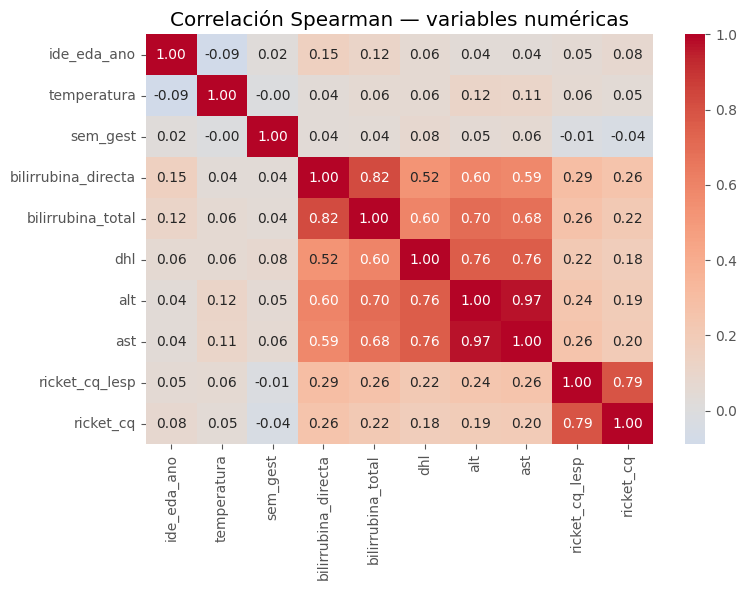

In [299]:
num_cols = rick.select_dtypes(include=['int', 'int64', 'float', 'float64']).columns

corr = rick[num_cols].corr(method='spearman')  # spearman es más robusto con datos clínicos

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlación Spearman — variables numéricas')
plt.tight_layout()
plt.show()

## **5. Análisis demográfico**

### 5.1 Distribución geográfica

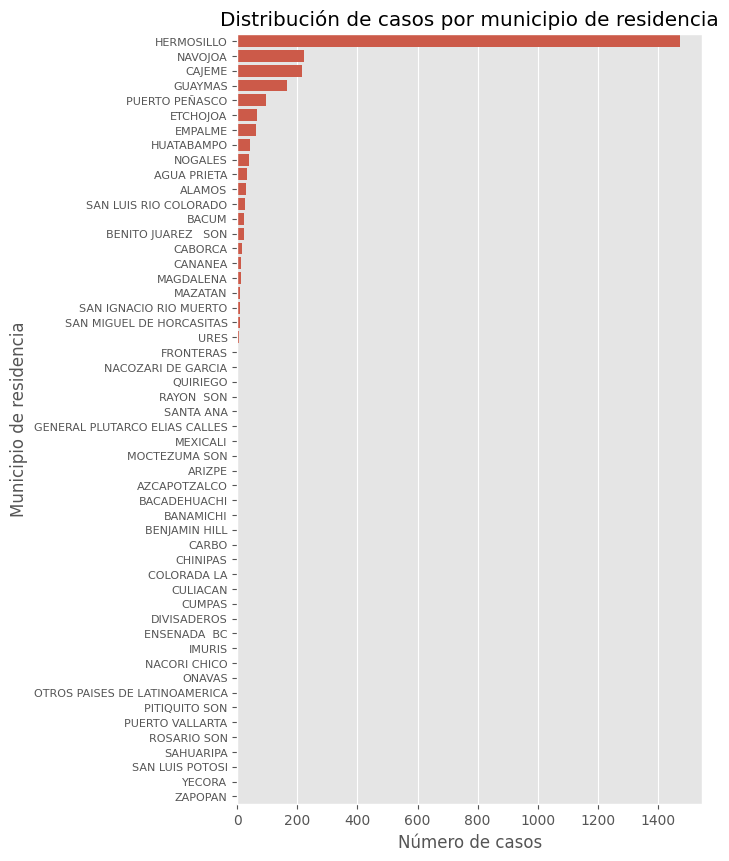

In [297]:
plt.figure(figsize=(6, 10))
sns.countplot(rick['des_mpo_res'], order=rick['des_mpo_res'].value_counts().index)
plt.title('Distribución de casos por municipio de residencia')
plt.ylabel('Municipio de residencia')
plt.xlabel('Número de casos')
plt.yticks(size = 8)
plt.show()

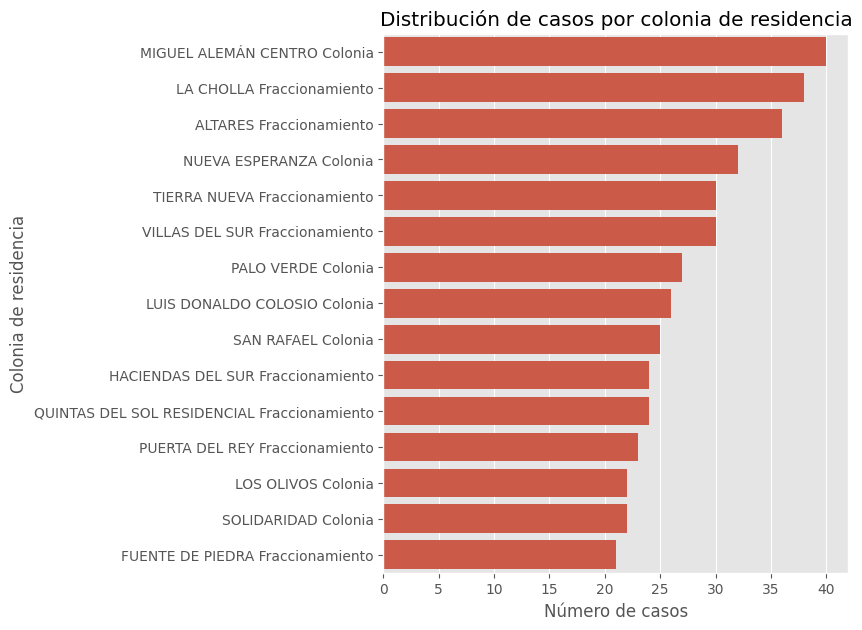

In [298]:
plt.figure(figsize=(6, 7))
sns.countplot(rick['ide_col'], order=rick['ide_col'].value_counts().head(15).index)
plt.title('Distribución de casos por colonia de residencia')
plt.ylabel('Colonia de residencia')
plt.xlabel('Número de casos')
plt.yticks(size = 10)
plt.show()

### 5.2 Edad y sexo

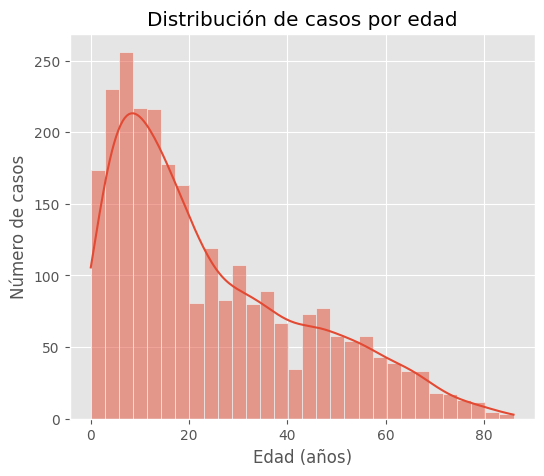

In [300]:
plt.figure(figsize=(6, 5))
sns.histplot(rick['ide_eda_ano'], bins=30, kde=True)
plt.title('Distribución de casos por edad')
plt.ylabel('Número de casos')
plt.xlabel('Edad (años)')
plt.show()

In [320]:
print(rick['ide_eda_ano'].describe())
print('--------------------')
print(f"\nMediana: {rick['ide_eda_ano'].median()}")
print(f"\nModa: {rick['ide_eda_ano'].mode().iloc[0]}")
print('--------------------')
print('\nEdades más frecuentes:')
rick['ide_eda_ano'].value_counts().head(15)

count    2631.000000
mean       24.320791
std        19.557143
min         0.000000
25%         8.000000
50%        18.000000
75%        37.000000
max        86.000000
Name: ide_eda_ano, dtype: float64
--------------------

Mediana: 18.0

Moda: 8
--------------------

Edades más frecuentes:


ide_eda_ano
8     93
5     91
9     85
7     84
14    83
6     79
4     78
11    73
15    71
1     71
12    67
13    66
3     61
16    60
10    59
Name: count, dtype: int64

C:\Users\fanny\AppData\Local\Temp\ipykernel_16376\1452807955.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(rick['ide_sex'], palette = 'Accent')


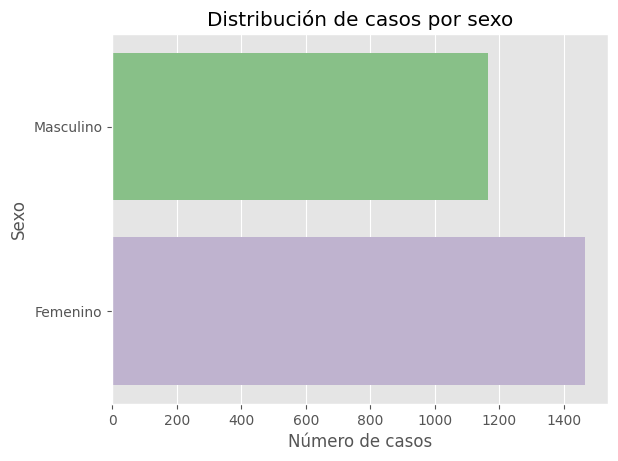

In [312]:
sns.countplot(rick['ide_sex'], palette = 'Accent')
plt.title('Distribución de casos por sexo')
plt.yticks(ticks = [0, 1], labels = ['Masculino', 'Femenino'])
plt.xlabel('Número de casos')
plt.ylabel('Sexo')
plt.show()

### 5.3 Variables clínicas

C:\Users\fanny\AppData\Local\Temp\ipykernel_16376\1843302674.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(rick['estatus_caso'], palette='Set2')
C:\Users\fanny\AppData\Local\Temp\ipykernel_16376\1843302674.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([mapeo_estatus_caso.get(int(t.get_text()), t.get_text())


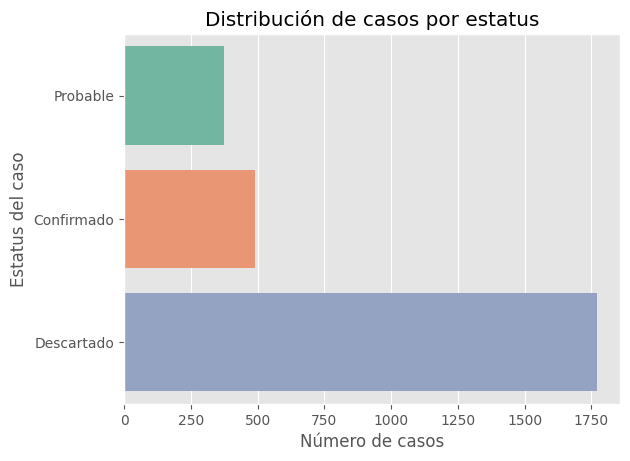

In [325]:
mapeo_estatus_caso = {1: 'Probable', 2: 'Confirmado', 3: 'Descartado'}

ax = sns.countplot(rick['estatus_caso'], palette='Set2')
ax.set_yticklabels([mapeo_estatus_caso.get(int(t.get_text()), t.get_text()) 
                    for t in ax.get_yticklabels()])
plt.title('Distribución de casos por estatus')
plt.ylabel('Estatus del caso')
plt.xlabel('Número de casos')
plt.show()

C:\Users\fanny\AppData\Local\Temp\ipykernel_16376\1332211908.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(rick['des_diag_final'], palette='Set2')


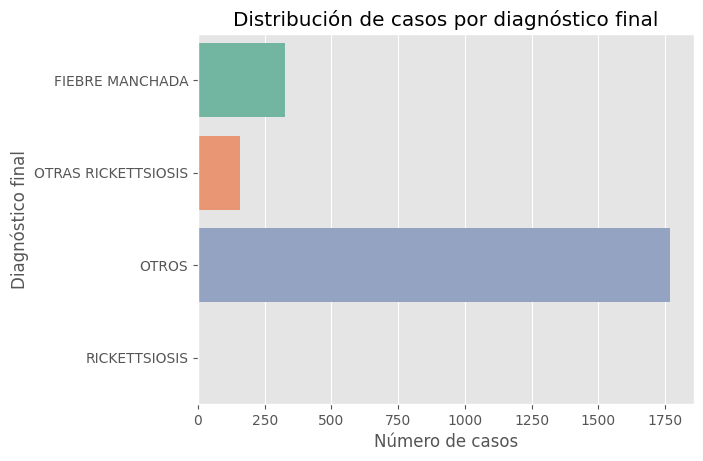

In [327]:
sns.countplot(rick['des_diag_final'], palette='Set2')
plt.title('Distribución de casos por diagnóstico final')
plt.ylabel('Diagnóstico final')
plt.xlabel('Número de casos')
plt.show()

count    2631.00000
mean       37.63626
std         6.07228
min         0.00000
25%        38.00000
50%        39.00000
75%        39.00000
max        43.00000
Name: temperatura, dtype: float64


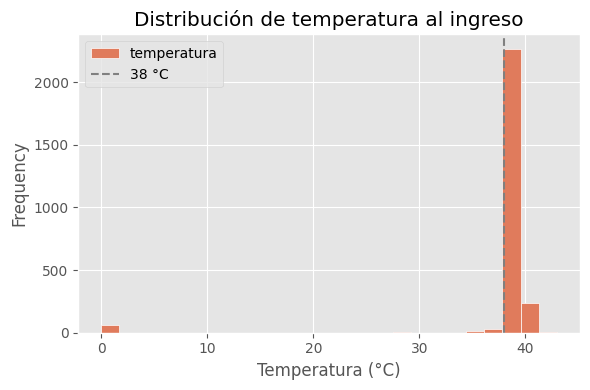

In [336]:
print(rick['temperatura'].describe())

fig, ax = plt.subplots(figsize=(6, 4))
rick['temperatura'].dropna().plot(kind='hist', bins=25, ax=ax,
    color='#E07B5C', edgecolor='white')
ax.axvline(38.0, color='gray', linestyle='--', label='38 °C')
ax.set_title('Distribución de temperatura al ingreso')
ax.set_xlabel('Temperatura (°C)')
ax.legend()
plt.tight_layout()
plt.show()